## Convocatoria 1 - Proyecto 1

#### 0) Cargar una de las imágenes histológicas

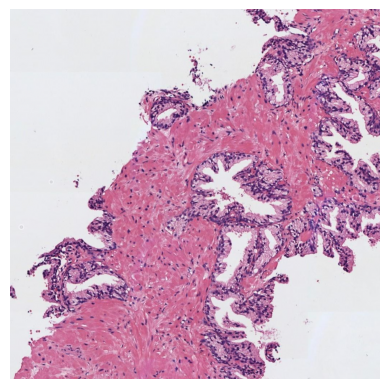

In [126]:
# Visualizar la imagen
import skimage.io as io
import numpy as np 
import matplotlib.pyplot as plt
import cv2


def load_and_normalize_image (image):
    # Utilizar la librería skimage.io para leer la imagen 'histo_x.jpg' en formato RGB.
    img = io.imread(image) 
    # Normalizar la imagen para que los píxeles se encuentren en el rango [0, 1]
    #esta línea convierte los valores de píxeles a float32 y los divide por 255 para normalizar a [0, 1]
    rgb_p = img.astype('uint8')/255
    return rgb_p



rgb_img = load_and_normalize_image(r'histo_1.jpg')  # Asegúrate de que la ruta sea correcta


# Visualizar la imagen normalizada
plt.imshow(rgb_img)
plt.axis('off')
plt.show()



#### 1) Realizar una transformación de color para convertir la imagen al espacio de color CMYK

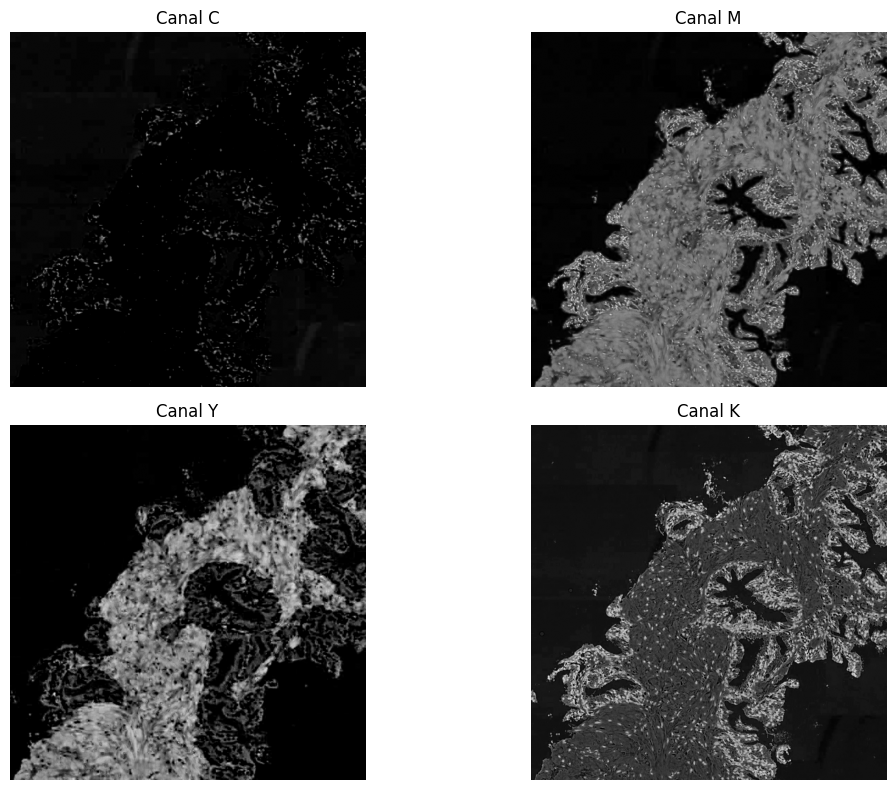

In [127]:
#convertir la imagen RGB a CMYK

# Función para extraer los colores secundarios
def convert_to_CMYK(RGB_image):
    with np.errstate(invalid='ignore', divide='ignore'):
        K = 1 - np.max(RGB_image, axis=2)
        C = (1-RGB_image[:,:,0] - K)/(1-K)
        M = (1-RGB_image[:,:,1] - K)/(1-K)
        Y = (1-RGB_image[:,:,2] - K)/(1-K)
    C = np.nan_to_num(C)
    M = np.nan_to_num(M)
    Y = np.nan_to_num(Y)
    K = np.nan_to_num(K)
    CMYK_image = (np.dstack((C,M,Y,K))*255).astype('uint8')
    return CMYK_image

CMYK = convert_to_CMYK(rgb_img)
C,M,Y,K = cv2.split(CMYK)

# Extraer canales los componente de la imagen (que corresponde a la región tisular)
# Visualizar la imagen de lo los canales C, M, Y y K
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(C, cmap='gray')
plt.title('Canal C')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(M, cmap='gray')
plt.title('Canal M')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(Y, cmap='gray')
plt.title('Canal Y')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(K, cmap='gray')
plt.title('Canal K')
plt.axis('off')
plt.tight_layout()
plt.show()





#### 2) Umbralizar la imagen para separar los píxeles del fondo de la región tisular

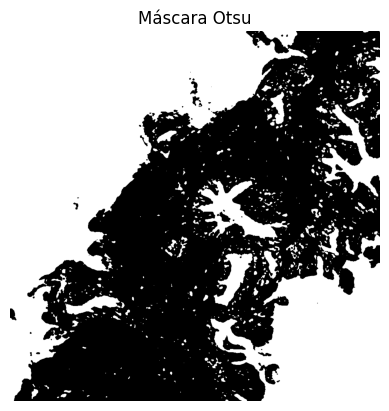

In [128]:
# A la imagen CMYK Aplicar un filtro gaussiano de tamaño 5x5 y después utilizar el método de Otsu de manera que
# los píxeles correspondientes al lumen y al background de la imagen sean 1s y el resto de los píxeles tengan un valor de 0.
# Nota: Recordar que el método de Otsu requiere como input una imagen en el rango [0-255] en formato "uint8".
# Visualizar la máscara resultante
# Aplicar un filtro gaussiano de tamaño 5x5

def generate_gauss_mask (cmyk_image):
    blurred = cv2.GaussianBlur(cmyk_image, (5, 5), 0)
    # Convertir la imagen a escala de grises
    gray = cv2.cvtColor(blurred, cv2.COLOR_BGR2GRAY)
    # Aplicar el método de Otsu para obtener la máscara
    _, gauss_mask = cv2.threshold(gray, 0, 1, cv2.THRESH_OTSU)
    # Invertir la imagen
    gauss_mask = 1 - gauss_mask
    return gauss_mask

#_, gauss_mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

gauss = generate_gauss_mask(CMYK)
# Visualizar la máscara resultante
plt.imshow(gauss, cmap='gray')
plt.axis('off')
plt.title('Máscara Otsu')
plt.show()


#### 3) Limpiar la imagen eliminando los artefactos de lumen (objetos blancos pequeños que no son lúmenes)

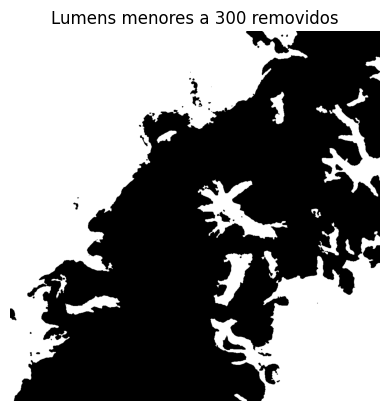

In [129]:
# Utilizar la librería skimage.morphology.remove_small_objects para eliminar aquellos objetos de la imagen CMYK cuya área sea menor a 300 píxeles usando la mascara gauss_mask
# Más información en https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.remove_small_objects
# Visualizaer la máscara resultante

# Aplicar remove_small_objects a la imagen CMYK

def clean_small_lumens (binary_img, min):
    from skimage.morphology import remove_small_objects
    # Eliminar objetos pequeños de la imagen CMYK
    cleaned_bool = remove_small_objects(binary_img.astype(bool), min, connectivity=2)
    cleaned_binary = cleaned_bool.astype(np.uint8)
    return cleaned_binary

gaus_cleaned = clean_small_lumens(gauss,300)
# Visualizar la mascara
plt.imshow(gaus_cleaned, cmap='gray')
plt.axis('off')
plt.title('Lumens menores a 300 removidos')
plt.show()


#### 4) Rellenar con 0s el fondo de la imagen para quedarnos únicamente con los lúmenes

In [130]:
# Funcion que recibe gaus_cleaned boolean ndarray y genera semillas para el foodfill
# Debe encontrar semillas en el background, para que luego el algoritmo de floodfill pueda rellenar el fondo y dejar los lumens intactos
def find_seeds(image, num_seeds=1):
    seeds = []
    h, w = image.shape

    # 1. Busca en los 4 vértices
    vertices = [(0, 0), (0, w-1), (h-1, 0), (h-1, w-1)]
    for y, x in vertices:
        if image[y, x] == 1:
            seeds.append((y, x))
        if len(seeds) >= num_seeds:
            return seeds[:num_seeds]

    # 2. Si faltan semillas, busca en toda la imagen
    if len(seeds) < num_seeds:
        coords = np.argwhere(image == 1)
        for y, x in coords:
            if (y, x) not in seeds:
                seeds.append((y, x))
            if len(seeds) >= num_seeds:
                break

    return seeds[:num_seeds]

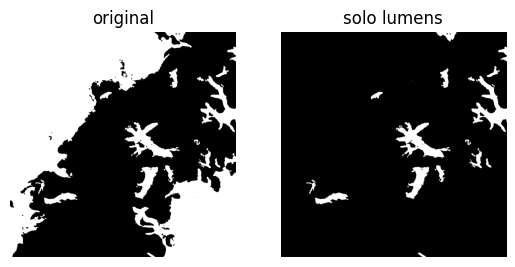

In [131]:
# Crear una copia de la imagen
just_lumens = gaus_cleaned.copy()
seeds = find_seeds(gaus_cleaned, 4)


# Definir una imagen negra de referencia
h, w = gaus_cleaned.shape
ref = np.zeros((h+2, w+2), np.uint8)

# Fijar la semilla. En este caso en la esquina superior izquierda (posición 0,0) para rellenar a partir de ahí
#cv2.floodFill(mask, ref, (0,1000), 0); # Como nos interesa rellenar de negro, utilizamos el 0 en la última posición
for _ in seeds:
    cv2.floodFill(just_lumens, ref, _, 0); # Como nos interesa rellenar de negro, utilizamos el 0 en la última posición

fig, ax = plt.subplots(1,2)
ax[0].imshow(gaus_cleaned, cmap='gray'), ax[0].set_title('original'), ax[0].axis('off')
ax[1].imshow(just_lumens, cmap='gray'), ax[1].set_title('solo lumens'), ax[1].axis('off')
plt.show()

#### 5) Rellenar los objetos de los lúmenes

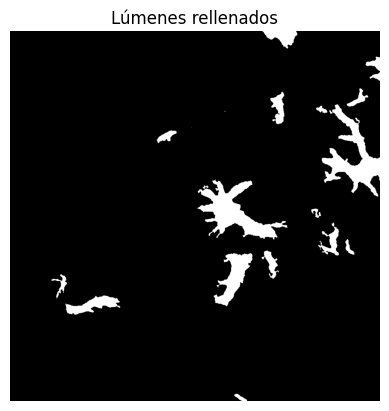

In [132]:
# Rellenar los lúmenes con la función binary_fill_holes de la librería scipy.ndimage.morphology
from scipy.ndimage import binary_fill_holes

# Rellenar los lúmenes en la imagen segmentada
filled_lumens = binary_fill_holes(just_lumens > 0)

# Visualizar la máscara resultante
plt.imshow(filled_lumens, cmap='gray')
plt.axis('off')
plt.title('Lúmenes rellenados')
plt.show()


#### 6) Detectar y dibujar los contornos de los lúmenes sobre la imagen original

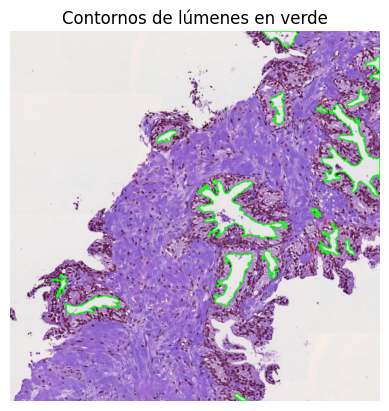

In [133]:
# Dibujar los contornos de los lúmenes en color verde sobre la imagen original RGB. Nota: Utilizar los flags necesarios para que los contornos en verde sean perfectamente visibles. 

# Detectar contornos en la máscara de lúmenes rellenados
contours, _ = cv2.findContours(filled_lumens.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Crear una copia de la imagen original en formato uint8
img_rgb = (rgb_img * 255).astype(np.uint8) if rgb_img.max() <= 1.0 else rgb_img.copy()

# Dibujar los contornos en verde (BGR: (0,255,0)) sobre la imagen original
img_contours = img_rgb.copy()
cv2.drawContours(img_contours, contours, -1, (0,255,0), thickness=2)

# Visualizar el resultado
plt.imshow(cv2.cvtColor(img_contours, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Contornos de lúmenes en verde')
plt.show()


#### 7) Identificar y cropear el lumen más grande

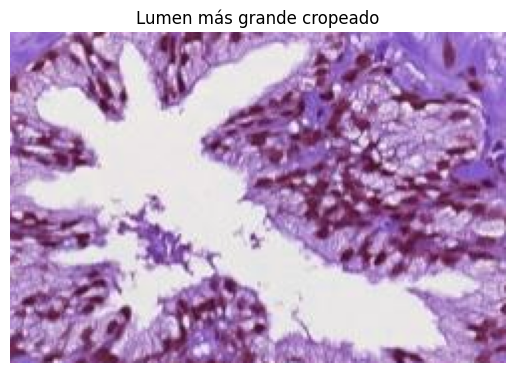

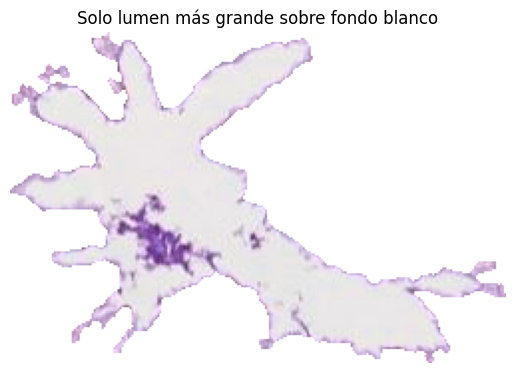

In [134]:
# Determinar cuál es el lumen de mayor área y hacer un crop del mismo sobre la imagen original RGB.

# Encontrar el contorno de mayor área (lumen más grande)
largest_contour = max(contours, key=cv2.contourArea)

# Obtener el bounding box del lumen más grande
x, y, w, h = cv2.boundingRect(largest_contour)

# Cropear el lumen sobre la imagen original RGB
cropped_lumen = img_rgb[y:y+h, x:x+w]

# Visualizar el lumen cropeado
plt.imshow(cv2.cvtColor(cropped_lumen, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Lumen más grande cropeado')
plt.show()

# Determinar cuál es el lumen de mayor área y hacer un crop del mismo sobre la imagen original RGB, 
# quedandose solo con ese lumen y el resto blanco

# Crear máscara del lumen más grande dentro del crop
mask_crop = np.zeros((h, w), dtype=np.uint8)
cv2.drawContours(mask_crop, [largest_contour - [x, y]], -1, 1, thickness=-1)

# Crear imagen blanca
crop_white_bg = np.ones_like(cropped_lumen) * 255

# Aplicar la máscara: donde mask_crop==1, mostrar el lumen, si no, blanco
for c in range(3):  # Para cada canal RGB
    crop_white_bg[:,:,c] = np.where(mask_crop == 1, cropped_lumen[:,:,c], 255)

# Visualizar el resultado
plt.imshow(cv2.cvtColor(crop_white_bg, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Solo lumen más grande sobre fondo blanco')
plt.show()


#### 8) Extraer 13 características geométricas que permitan caracterizar el lumen recortado 

In [135]:
# Calcular las siguientes características del crop del lumen de mayor área, redondeando su valor hasta el cuarto decimal.
# 1) Área
# 2) Área de la bounding box
# 3) Área convexa
# 4) Exentricidad
# 5) Diámetro equivalente
# 6) Extensión
# 7) Diámetro Feret
# 8) Longitud del eje mayor
# 9) Longitud del eje menor
# 10) Orientación
# 11) Perímetro
# 12) Solidez
# 13) Compacidad



from skimage.measure import regionprops, label
from scipy.spatial import ConvexHull

# Crear máscara del lumen más grande dentro del crop
mask_crop = np.zeros((h, w), dtype=np.uint8)
cv2.drawContours(mask_crop, [largest_contour - [x, y]], -1, 1, thickness=-1)

# Calcular propiedades geométricas
props = regionprops(label(mask_crop))[0]
contour_points = largest_contour - [x, y]

# 1) Área
area = np.round(props.area, 4)
# 2) Área de la bounding box
bbox_area = np.round(props.bbox_area, 4)
# 3) Área convexa
hull = ConvexHull(contour_points.squeeze())
convex_area = np.round(hull.volume, 4)
# 4) Excentricidad
eccentricity = np.round(props.eccentricity, 4)
# 5) Diámetro equivalente
equiv_diameter = np.round(props.equivalent_diameter, 4)
# 6) Extensión
extent = np.round(props.extent, 4)
# 7) Diámetro Feret (máxima distancia entre dos puntos del contorno)
from scipy.spatial.distance import pdist
feret_diameter = np.round(np.max(pdist(contour_points.squeeze())), 4)
# 8) Longitud del eje mayor
major_axis_length = np.round(props.major_axis_length, 4)
# 9) Longitud del eje menor
minor_axis_length = np.round(props.minor_axis_length, 4)
# 10) Orientación
orientation = np.round(props.orientation, 4)
# 11) Perímetro
perimeter = np.round(props.perimeter, 4)
# 12) Solidez
solidity = np.round(props.solidity, 4)
# 13) Compacidad (perímetro^2 / (4*pi*área))
compacity = np.round((perimeter**2) / (4 * np.pi * area), 4)

# Mostrar resultados
features = {
    "Área": area,
    "Área bounding box": bbox_area,
    "Área convexa": convex_area,
    "Excentricidad": eccentricity,
    "Diámetro equivalente": equiv_diameter,
    "Extensión": extent,
    "Diámetro Feret": feret_diameter,
    "Longitud eje mayor": major_axis_length,
    "Longitud eje menor": minor_axis_length,
    "Orientación": orientation,
    "Perímetro": perimeter,
    "Solidez": solidity,
    "Compacidad": compacity
}

for k, v in features.items():
    print(f"{k}: {v}")

Área: 14555.0
Área bounding box: 41334.0
Área convexa: 31224.5
Excentricidad: 0.8463
Diámetro equivalente: 136.1323
Extensión: 0.3521
Diámetro Feret: 266.852
Longitud eje mayor: 242.8441
Longitud eje menor: 129.3499
Orientación: 1.0081
Perímetro: 1392.6215
Solidez: 0.4615
Compacidad: 10.6034
